
# Evaluación del Mejor Modelo de Optuna en MNIST (PyTorch)

Este notebook muestra cómo ejecutar Optuna, reconstruir el mejor modelo encontrado, entrenarlo sobre todo el conjunto de entrenamiento y evaluarlo en el conjunto de prueba.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import optuna
from optuna.samplers import RandomSampler

## Dataset

In [2]:
# Dataset y transformaciones
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

## Definición del modelo

In [3]:
# Definición del modelo
class SimpleNet(nn.Module):
    def __init__(self, n_units, dropout_rate):
        super(SimpleNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, n_units)
        self.fc2 = nn.Linear(n_units, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        z1 = self.dropout(self.relu(self.fc1(self.flatten(x)))) # 784
        z2 = self.fc2(z1)
        return z2

## Definición de la sintonización de hiperparámetros

In [4]:
# La función objective recibe el obejto trial y retorna alguna medida de desempeño.
# Debe incluir la definición, entrenamiento y validación del modelo.
def objective(trial):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(torch.cuda.is_available())
    print(device)

    # Espacio de búsqueda.
    # Dependiendo del algoritmo de muestreo se eligen:
    # a) todos los valores.
    # b) valores al azar.
    # c) valores según algún criterio de búsqueda (Bayesian Optimization)
    n_units = trial.suggest_int('n_units', 32, 256)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD'])

    # Definición del modelo.
    model = SimpleNet(n_units, dropout_rate).to(device)

    # Se define el optimzador de acuerdo con la búsqueda.
    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)
    else:
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    # Función de costo.
    criterion = nn.CrossEntropyLoss()

    # Recordar que para la búsqueda de hiperparámetros se usan 3 conjuntos: Train,
    # Validation y Test.
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

    # Ciclo de entrenamiento del modelo
    model.train()
    for epoch in range(5):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

    # Evaluación sobre el conjunto de validación
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)

    # Se retorna el error, así que se búsca minimizar el error. Tmabién puede ser
    # que se quiera maximizar el accuracy.
    val_accuracy = correct / total
    return 1.0 - val_accuracy


In [5]:
# Se define el objeto study encargado de realizar la búsqueda. Por defecto se
# usa un sampler = TPESampler, pero puede usarse cualquiera en este listado:
# https://optuna-readthedocs-io.translate.goog/en/stable/tutorial/10_key_features/003_efficient_optimization_algorithms.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc#pruning
study = optuna.create_study(direction='minimize')
# study = optuna.create_study(direction='minimize', sampler=RandomSampler())
print(f"Sampler is {study.sampler.__class__.__name__}")
study.optimize(objective, n_trials=10) #Se pasa la función objective y se define
# la cantidad máxima de iteraciones.

[I 2026-05-23 22:17:54,018] A new study created in memory with name: no-name-1706fefe-65ff-4bde-bd2d-1c364e49e731


Sampler is TPESampler
True
cuda


[I 2026-05-23 22:18:37,787] Trial 0 finished with value: 0.2865833333333333 and parameters: {'n_units': 212, 'dropout_rate': 0.24962480512759033, 'learning_rate': 0.00040725285626469493, 'optimizer': 'SGD'}. Best is trial 0 with value: 0.2865833333333333.


True
cuda


[I 2026-05-23 22:19:18,311] Trial 1 finished with value: 0.07799999999999996 and parameters: {'n_units': 33, 'dropout_rate': 0.11848507147009282, 'learning_rate': 0.0003236388019493089, 'optimizer': 'Adam'}. Best is trial 1 with value: 0.07799999999999996.


...

[I 2026-05-23 22:22:59,640] Trial 7 finished with value: 0.057083333333333375 and parameters: {'n_units': 144, 'dropout_rate': 0.2585629224767266, 'learning_rate': 0.00026862760522089214, 'optimizer': 'Adam'}. Best is trial 3 with value: 0.04074999999999995.


True
cuda


[I 2026-05-23 22:23:36,923] Trial 8 finished with value: 0.053583333333333316 and parameters: {'n_units': 161, 'dropout_rate': 0.2114704930066884, 'learning_rate': 0.0003770110113850853, 'optimizer': 'RMSprop'}. Best is trial 3 with value: 0.04074999999999995.


True
cuda


[I 2026-05-23 22:24:13,688] Trial 9 finished with value: 0.08825000000000005 and parameters: {'n_units': 50, 'dropout_rate': 0.4151223910565358, 'learning_rate': 0.00021109694658997906, 'optimizer': 'RMSprop'}. Best is trial 3 with value: 0.04074999999999995.


## Visualización de resultados

In [6]:
print('Mejores parámetros encontrados:')
print(study.best_params)

Mejores parámetros encontrados:
{'n_units': 216, 'dropout_rate': 0.2776217953697996, 'learning_rate': 0.0029896833714015427, 'optimizer': 'Adam'}


/tmp/ipykernel_1203/1317441400.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

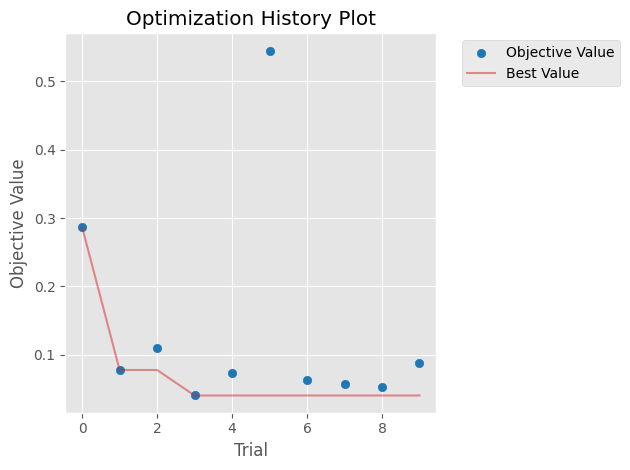

In [7]:
import optuna.visualization.matplotlib
optuna.visualization.matplotlib.plot_optimization_history(study)

In [8]:
optuna.visualization.plot_param_importances(study)

## Reentrenamiento del modelo con los mejores hiperparámetros y evaluación final sobre el conjunto de prueba.

In [9]:
# Extraer mejores hiperparámetros
best_params = study.best_params
n_units = best_params['n_units']
dropout_rate = best_params['dropout_rate']
optimizer_name = best_params['optimizer']
learning_rate = best_params['learning_rate']


In [10]:
# Reconstruir modelo final
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleNet(n_units, dropout_rate).to(device)

if optimizer_name == 'Adam':
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
elif optimizer_name == 'RMSprop':
    optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)
else:
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

criterion = nn.CrossEntropyLoss()

In [11]:
# Entrenar con todo el conjunto de entrenamiento
full_train_loader = DataLoader(dataset, batch_size=128, shuffle=True)
num_epochs = 10

model.train()
for epoch in range(num_epochs):
    for data, target in full_train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()


In [12]:

# Evaluar en el conjunto de prueba
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

model.eval()
correct = 0
total = 0
test_loss = 0.0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        test_loss += criterion(output, target).item()
        pred = output.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)

avg_test_loss = test_loss / len(test_loader)
test_accuracy = correct / total

print(f'Test accuracy: {test_accuracy:.4f}')
print(f'Test loss: {avg_test_loss:.4f}')


Test accuracy: 0.9689
Test loss: 0.1094


## Repetir para búsqueda aleatoria

In [13]:
# Se define el objeto study encargado de realizar la búsqueda. Por defecto se
# usa un sampler = TPESampler, pero puede usarse cualquiera en este listado:
# https://optuna-readthedocs-io.translate.goog/en/stable/tutorial/10_key_features/003_efficient_optimization_algorithms.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc#pruning
study = optuna.create_study(direction='minimize', sampler=RandomSampler())
print(f"Sampler is {study.sampler.__class__.__name__}")
study.optimize(objective, n_trials=10) #Se pasa la función objective y se define
# la cantidad máxima de iteraciones.

[I 2026-05-23 22:27:43,413] A new study created in memory with name: no-name-af7b590f-ffc7-4f4e-acff-98f5f790acc8


Sampler is RandomSampler
True
cuda


[I 2026-05-23 22:28:19,643] Trial 0 finished with value: 0.13316666666666666 and parameters: {'n_units': 245, 'dropout_rate': 0.476110163393478, 'learning_rate': 0.003081006077879021, 'optimizer': 'SGD'}. Best is trial 0 with value: 0.13316666666666666.


True
cuda


[I 2026-05-23 22:28:55,197] Trial 1 finished with value: 0.5235000000000001 and parameters: {'n_units': 56, 'dropout_rate': 0.14545717401660663, 'learning_rate': 0.00022695633995645402, 'optimizer': 'SGD'}. Best is trial 0 with value: 0.13316666666666666.


...

[I 2026-05-23 22:32:37,766] Trial 7 finished with value: 0.05800000000000005 and parameters: {'n_units': 65, 'dropout_rate': 0.2771755356106288, 'learning_rate': 0.002630695466116526, 'optimizer': 'Adam'}. Best is trial 4 with value: 0.04600000000000004.


True
cuda


[I 2026-05-23 22:33:13,794] Trial 8 finished with value: 0.6015833333333334 and parameters: {'n_units': 86, 'dropout_rate': 0.16566640489528583, 'learning_rate': 0.00012374649773419513, 'optimizer': 'SGD'}. Best is trial 4 with value: 0.04600000000000004.


True
cuda


[I 2026-05-23 22:33:51,566] Trial 9 finished with value: 0.07308333333333328 and parameters: {'n_units': 61, 'dropout_rate': 0.227130495829702, 'learning_rate': 0.0006322552604483784, 'optimizer': 'RMSprop'}. Best is trial 4 with value: 0.04600000000000004.


/tmp/ipykernel_1203/1317441400.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

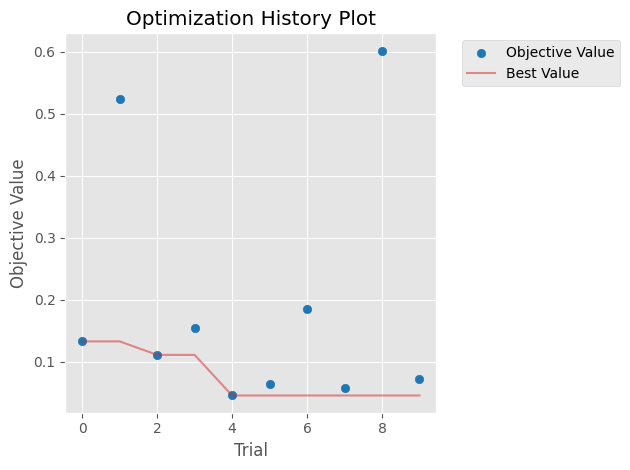

In [14]:
import optuna.visualization.matplotlib
optuna.visualization.matplotlib.plot_optimization_history(study)

## Actividad: Búsqueda de hiperparámetros

Para la base de datos Fashion Mnist, realizar una búsqueda de hiperparámetros que incluya:

1. Número adecuado de capas.
2. Número de neuronas por capa.
3. Tamaño del lote.
4. Learning Rate.

In [15]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

## Definición del modelo

In [16]:
# Definición del modelo
class SimpleNet(nn.Module):
    def __init__(self, n_units, dropout_rate):
        super(SimpleNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, n_units)
        self.fc2 = nn.Linear(n_units, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        z1 = self.dropout(self.relu(self.fc1(self.flatten(x)))) # 784
        z2 = self.fc2(z1)
        return z2

## Definición de la sintonización de hiperparámetros

In [17]:
# La función objective recibe el obejto trial y retorna alguna medida de desempeño.
# Debe incluir la definición, entrenamiento y validación del modelo.
def objective(trial):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(torch.cuda.is_available())
    print(device)

    # Espacio de búsqueda.
    # Dependiendo del algoritmo de muestreo se eligen:
    # a) todos los valores.
    # b) valores al azar.
    # c) valores según algún criterio de búsqueda (Bayesian Optimization)
    n_units = trial.suggest_int('n_units', 32, 256)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD'])

    # Definición del modelo.
    model = SimpleNet(n_units, dropout_rate).to(device)

    # Se define el optimzador de acuerdo con la búsqueda.
    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)
    else:
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    # Función de costo.
    criterion = nn.CrossEntropyLoss()

    # Recordar que para la búsqueda de hiperparámetros se usan 3 conjuntos: Train,
    # Validation y Test.
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

    # Ciclo de entrenamiento del modelo
    model.train()
    for epoch in range(5):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

    # Evaluación sobre el conjunto de validación
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)

    # Se retorna el error, así que se búsca minimizar el error. Tmabién puede ser
    # que se quiera maximizar el accuracy.
    val_accuracy = correct / total
    return 1.0 - val_accuracy


In [18]:
# Se define el objeto study encargado de realizar la búsqueda. Por defecto se
# usa un sampler = TPESampler, pero puede usarse cualquiera en este listado:
# https://optuna-readthedocs-io.translate.goog/en/stable/tutorial/10_key_features/003_efficient_optimization_algorithms.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc#pruning
study = optuna.create_study(direction='minimize')
# study = optuna.create_study(direction='minimize', sampler=RandomSampler())
print(f"Sampler is {study.sampler.__class__.__name__}")
study.optimize(objective, n_trials=10) #Se pasa la función objective y se define
# la cantidad máxima de iteraciones.

[I 2026-05-23 22:40:35,946] A new study created in memory with name: no-name-d6a32404-bcb0-4b43-88ea-2a7125641c2d


Sampler is TPESampler
True
cuda


[I 2026-05-23 22:41:14,614] Trial 0 finished with value: 0.13883333333333336 and parameters: {'n_units': 140, 'dropout_rate': 0.4771463823299851, 'learning_rate': 0.0014956495126073354, 'optimizer': 'RMSprop'}. Best is trial 0 with value: 0.13883333333333336.


True
cuda


[I 2026-05-23 22:41:55,735] Trial 1 finished with value: 0.2300833333333333 and parameters: {'n_units': 38, 'dropout_rate': 0.2783893025211416, 'learning_rate': 0.003198682734244796, 'optimizer': 'SGD'}. Best is trial 0 with value: 0.13883333333333336.


...

[I 2026-05-23 22:45:50,671] Trial 7 finished with value: 0.1316666666666667 and parameters: {'n_units': 240, 'dropout_rate': 0.46714330074511434, 'learning_rate': 0.0003766680415766951, 'optimizer': 'RMSprop'}. Best is trial 7 with value: 0.1316666666666667.


True
cuda


[I 2026-05-23 22:46:26,832] Trial 8 finished with value: 0.21825000000000006 and parameters: {'n_units': 109, 'dropout_rate': 0.12960028079411137, 'learning_rate': 0.0034883356292520263, 'optimizer': 'SGD'}. Best is trial 7 with value: 0.1316666666666667.


True
cuda


[I 2026-05-23 22:47:02,452] Trial 9 finished with value: 0.5904166666666666 and parameters: {'n_units': 67, 'dropout_rate': 0.1637677237715277, 'learning_rate': 0.00011665308688130739, 'optimizer': 'SGD'}. Best is trial 7 with value: 0.1316666666666667.


## Visualización de resultados

In [19]:
print('Mejores parámetros encontrados:')
print(study.best_params)

Mejores parámetros encontrados:
{'n_units': 240, 'dropout_rate': 0.46714330074511434, 'learning_rate': 0.0003766680415766951, 'optimizer': 'RMSprop'}


/tmp/ipykernel_1203/1317441400.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

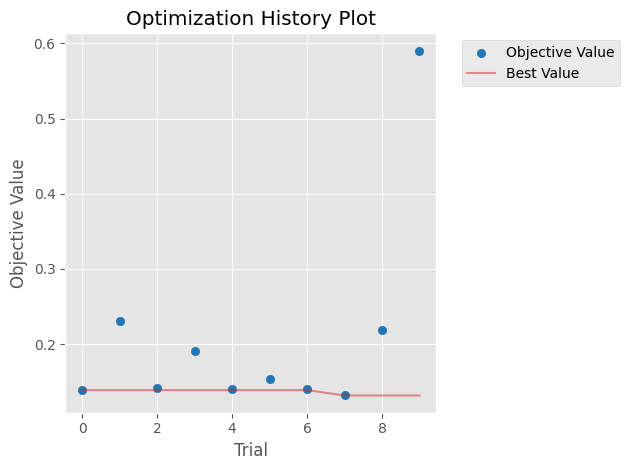

In [20]:
import optuna.visualization.matplotlib
optuna.visualization.matplotlib.plot_optimization_history(study)

In [21]:
optuna.visualization.plot_param_importances(study)

## Reentrenamiento del modelo con los mejores hiperparámetros y evaluación final sobre el conjunto de prueba.

In [22]:
# Extraer mejores hiperparámetros
best_params = study.best_params
n_units = best_params['n_units']
dropout_rate = best_params['dropout_rate']
optimizer_name = best_params['optimizer']
learning_rate = best_params['learning_rate']


In [23]:
# Reconstruir modelo final
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleNet(n_units, dropout_rate).to(device)

if optimizer_name == 'Adam':
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
elif optimizer_name == 'RMSprop':
    optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)
else:
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

criterion = nn.CrossEntropyLoss()

In [24]:
# Entrenar con todo el conjunto de entrenamiento
full_train_loader = DataLoader(dataset, batch_size=128, shuffle=True)
num_epochs = 10

model.train()
for epoch in range(num_epochs):
    for data, target in full_train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()


In [25]:

# Evaluar en el conjunto de prueba
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

model.eval()
correct = 0
total = 0
test_loss = 0.0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        test_loss += criterion(output, target).item()
        pred = output.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)

avg_test_loss = test_loss / len(test_loader)
test_accuracy = correct / total

print(f'Test accuracy: {test_accuracy:.4f}')
print(f'Test loss: {avg_test_loss:.4f}')


Test accuracy: 0.8730
Test loss: 0.3495
